# Tutoriel CNN : Classification Chat vs Chien avec TensorFlow

Ce notebook est conçu pour les débutants. Nous allons apprendre à :
1. Charger et préparer un jeu de données d'images.
2. Visualiser les données d'entraînement.
3. Construire un Réseau de Neurones Convolutif (CNN).
4. Entraîner le modèle et visualiser ses performances.
5. Faire des prédictions et afficher les résultats.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow_datasets as tfds

print("Version de TensorFlow:", tf.__version__)

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

Version de TensorFlow: 2.20.0


In [2]:
# Téléchargement du dataset officiel (Microsoft Cats vs Dogs)
!wget --no-check-certificate https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -O /tmp/cats_vs_dogs.zip

# Décompression
import zipfile
import os

local_zip = '/tmp/cats_vs_dogs.zip'
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('/tmp/extracted')

# Nettoyage : Le zip contient un dossier 'PetImages' avec 'Cat' et 'Dog'
# On supprime les fichiers corrompus connus (Thumps.db)
!find /tmp/extracted/PetImages -name "*.db" -delete

print("Décompression terminée. Les images sont dans /tmp/extracted/PetImages")

--2026-06-17 20:13:32--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.210.18.67, 2a02:26f0:6d00:3b6::317f, 2a02:26f0:6d00:39f::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.210.18.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/tmp/cats_vs_dogs.zip’

/tmp/cats_vs_dogs.z 100%[===================>] 786.67M   119MB/s    in 10s     

2026-06-17 20:13:43 (76.4 MB/s) - ‘/tmp/cats_vs_dogs.zip’ saved [824887076/824887076]

Décompression terminée. Les images sont dans /tmp/extracted/PetImages


In [3]:
# Chargement des données locales avec Keras
IMG_SIZE = 128
BATCH_SIZE = 32
BASE_DIR = '/tmp/extracted/PetImages'

# Création du dataset d'entraînement
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Création du dataset de validation
validation_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes détectées : {class_names}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Classes détectées : ['Cat', 'Dog']


## 2. Visualisation des images
Avant de traiter les données, regardons à quoi elles ressemblent.

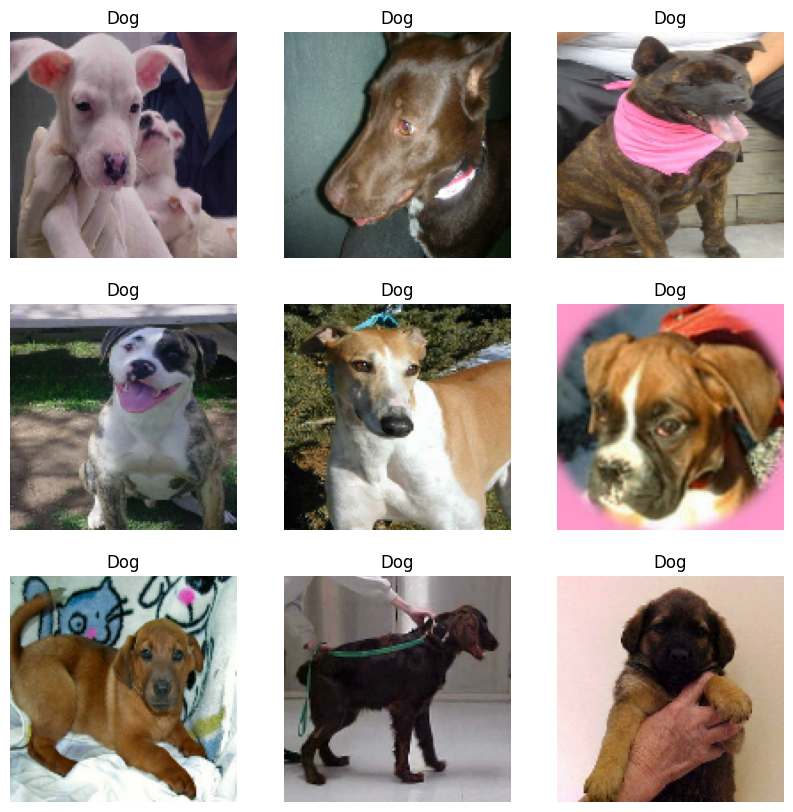

In [4]:
# Visualisation des images chargées localement
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## 3. Prétraitement
Les images ont des tailles différentes. Nous devons les redimensionner à une taille fixe (ex: 128x128) et normaliser les pixels entre 0 et 1.

In [5]:
# Prétraitement : Normalisation
# Note: Le redimensionnement est déjà fait lors du chargement avec image_dataset_from_directory

# Nous appliquons une fonction de normalisation simple (mise à l'échelle des pixels)
normalization_layer = layers.Rescaling(1./127.5, offset=-1)

train = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation = validation_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimisation des performances
AUTOTUNE = tf.data.AUTOTUNE
train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation = validation.cache().prefetch(buffer_size=AUTOTUNE)

## 4. Construction du modèle CNN
Un CNN utilise des couches de convolution pour extraire des caractéristiques (formes, textures) et des couches de pooling pour réduire la dimension.

In [6]:
# Définition et compilation du module
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Couches denses
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entraînement
Nous allons entraîner le modèle sur quelques époques pour l'exemple.

In [7]:
import os
import numpy as np
from PIL import Image

# 1. Nettoyage ULTIME : on décode réellement chaque image pour être sûr
print("Vérification approfondie des images (décodage complet)...")
num_skipped = 0
for folder in ['Cat', 'Dog']:
    folder_path = os.path.join(BASE_DIR, folder)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img = Image.open(file_path)
            # On force le décodage complet en convertissant en array
            _ = np.array(img)
        except Exception:
            if os.path.exists(file_path):
                os.remove(file_path)
                num_skipped += 1

print(f"Supprimé {num_skipped} images corrompues au décodage.")

Vérification approfondie des images (décodage complet)...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Supprimé 2 images corrompues au décodage.


In [8]:
# 2. Re-génération des datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR, validation_split=0.2, subset='training', seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR, validation_split=0.2, subset='validation', seed=123,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [9]:
# 3. Prétraitement
normalization_layer = layers.Rescaling(1./127.5, offset=-1)
train = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation = validation_ds.map(lambda x, y: (normalization_layer(x), y))
train = train.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation = validation.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [10]:
import os

# 1. Nettoyage spécifique pour TensorFlow (élimine les erreurs de header)
print("Vérification de la compatibilité TensorFlow...")
num_removed = 0
for folder in ['Cat', 'Dog']:
    folder_path = os.path.join(BASE_DIR, folder)
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img_bytes = tf.io.read_file(file_path)
            # On tente le décodage strict utilisé par le moteur d'entraînement
            tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        except Exception:
            if os.path.exists(file_path):
                os.remove(file_path)
                num_removed += 1

if num_removed > 0:
    print(f"Supprimé {num_removed} images incompatibles avec le décodeur TF.")
    # On doit recréer les datasets car les fichiers sur le disque ont changé
    train_ds = tf.keras.utils.image_dataset_from_directory(
        BASE_DIR, validation_split=0.2, subset='training', seed=123,
        image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
    )
    validation_ds = tf.keras.utils.image_dataset_from_directory(
        BASE_DIR, validation_split=0.2, subset='validation', seed=123,
        image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
    )
    train = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
    validation = validation_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
else:
    print("Toutes les images sont compatibles.")

# 2. Relance de l'entraînement
print("Début de l'entraînement...")
history = model.fit(train, epochs=5, validation_data=validation)

Vérification de la compatibilité TensorFlow...
Supprimé 7 images incompatibles avec le décodeur TF.
Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.
Début de l'entraînement...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.6507 - loss: 0.6128 - val_accuracy: 0.7511 - val_loss: 0.5122
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7693 - loss: 0.4859 - val_accuracy: 0.8025 - val_loss: 0.4267
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8226 - loss: 0.4031 - val_accuracy: 0.8299 - val_loss: 0.3743
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8557 - loss: 0.3379 - val_accuracy: 0.8533 - val_loss: 0.3387
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8823 - loss: 0.2796 - val_accuracy: 0.8711 - val_loss: 0.3103


## 6. Analyse des résultats
Affichons l'évolution de la précision au cours du temps.

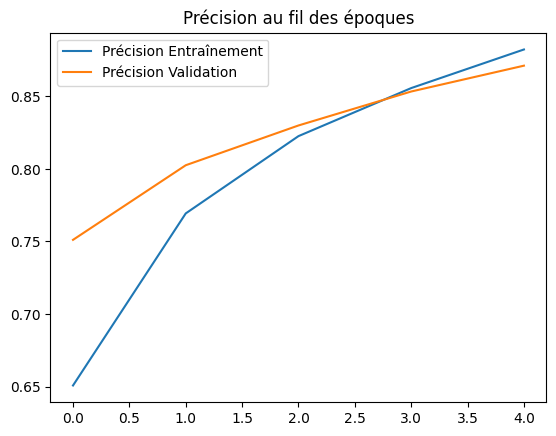

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Précision Entraînement')
plt.plot(val_acc, label='Précision Validation')
plt.legend()
plt.title('Précision au fil des époques')
plt.show()

## 7. Prédictions visuelles
Enfin, testons notre modèle sur des images de validation.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


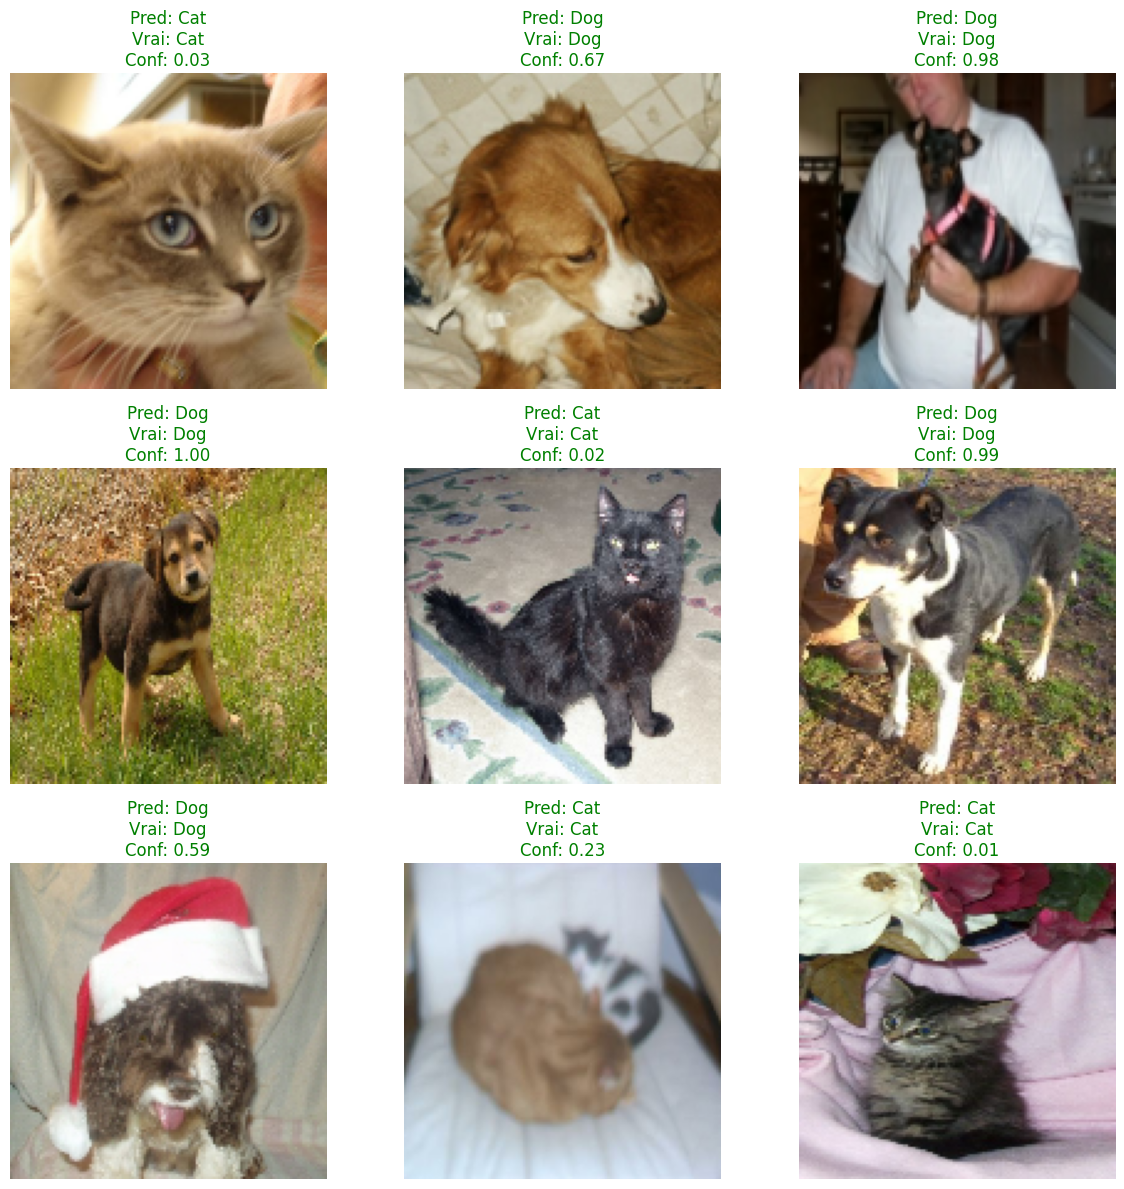

In [12]:
# Prédictions visuelles avec le nouveau dataset
# On s'assure que le module est bien présent avant de prédire
if 'model' in globals():
    image_batch, label_batch = next(iter(validation))
    predictions = model.predict(image_batch)

    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img_display = (image_batch[i].numpy() + 1) / 2
        plt.imshow(np.clip(img_display, 0, 1))

        pred_idx = 1 if predictions[i] > 0.5 else 0
        pred_label = class_names[pred_idx]
        true_label = class_names[label_batch[i]]

        color = "green" if pred_idx == label_batch[i] else "red"
        plt.title(f"Pred: {pred_label}\nVrai: {true_label}\nConf: {predictions[i][0]:.2f}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Erreur : Le module n'est pas défini. Veuillez réexécuter la cellule de construction du module.")